## Implementation of Multiple Linear Rgression

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [65]:
df=pd.read_csv("../data/economic_index.csv")
df.head(5)

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [66]:
df.drop(columns=['Unnamed: 0', 'year', 'month'], axis=1, inplace=True)
df.head(5)

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [67]:
df.isna().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

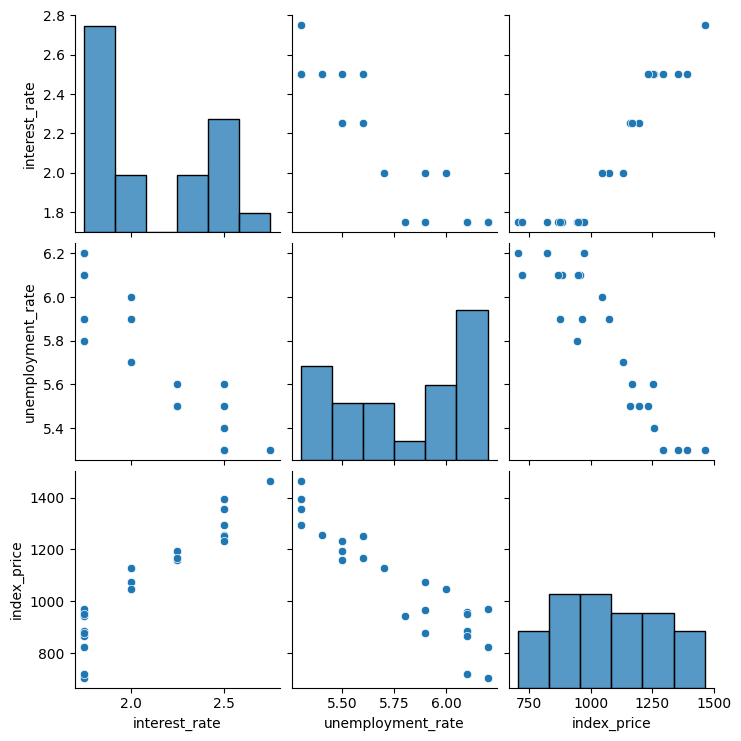

In [68]:
sns.pairplot(df)

In [69]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

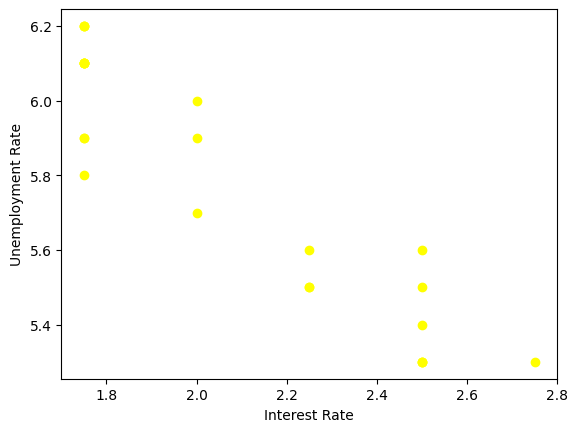

In [70]:
plt.scatter(df['interest_rate'],df['unemployment_rate'], color='yellow')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')

In [71]:
#Splitting the data into training and testing sets
X=df.iloc[:, :-1]
y=df.iloc[:, -1]

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

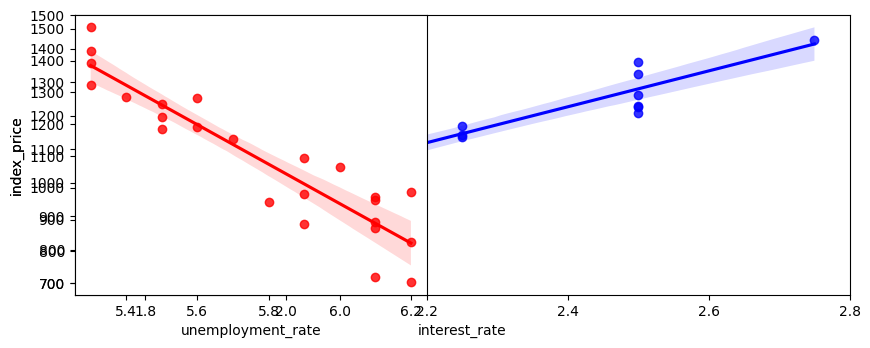

In [73]:
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
sns.regplot(x=df['interest_rate'], y=df['index_price'], color='blue')
plt.subplot(2, 2, 1)
sns.regplot(x=df['unemployment_rate'], y=df['index_price'], color='red')

In [74]:
#Standardization of the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [75]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
## Cross-validation : It is a technique used to evaluate the performance of a machine learning model by splitting the data into multiple subsets (folds) and training/testing the model on different combinations of these subsets. This helps to ensure that the model's performance is not dependent on a specific train-test split and provides a more robust estimate of its generalization ability 
validation_score = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print("Cross-validation scores:", validation_score)

Cross-validation scores: [-1606.47408206 -9579.95329208 -7961.60935985 -8392.32547433
  -773.2668524 ]


In [77]:
y_pred=model.predict(X_test)

In [78]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)  
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 6957.105303258833
Mean Absolute Error: 71.71878409976625
Root Mean Squared Error: 83.40926389351985


In [79]:
r2_score = r2_score(y_test, y_pred)
print("R-squared Score:", r2_score)

R-squared Score: 0.8254940547158576


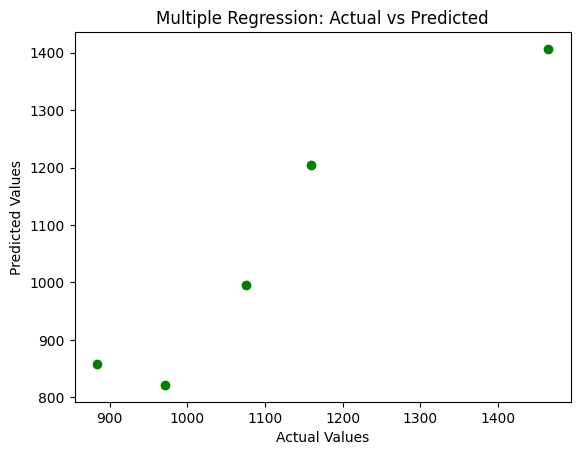

In [81]:
plt.scatter(y_test, y_pred, color='green')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Regression: Actual vs Predicted")
plt.show()

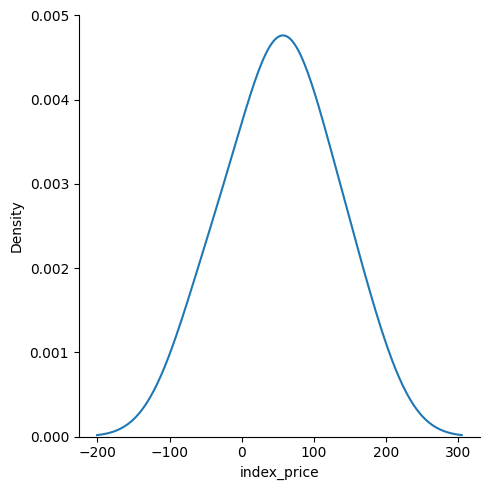

In [85]:
residuals = y_test - y_pred
sns.displot(residuals, kind='kde')